In [3]:
!git clone https://github.com/andreiionut1411/trustworthy-federated-skin-lesion.git

fatal: destination path 'trustworthy-federated-skin-lesion' already exists and is not an empty directory.


In [5]:
!pip install flwr[simulation] torch torchvision pandas numpy

INFO: pip is looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
!pip install -r /content/trustworthy-federated-skin-lesion/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 140.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 761.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 158.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 147.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip "/content/drive/MyDrive/AITDM/train.zip" -d /content

Archive:  /content/drive/MyDrive/AITDM/train.zip
replace /content/train/ISIC_9712403.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
import os
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from PIL import Image
from collections import OrderedDict
import flwr as fl

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH = "/content/trustworthy-federated-skin-lesion/labels/ISIC_2020_Training_GroundTruth.csv"
IMG_DIR = "/content/train"
NUM_CLIENTS = 3
NUM_ROUNDS = 5
BATCH_SIZE = 32

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything()
print(f"Setup complete. Device: {DEVICE}")

Setup complete. Device: cuda


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
class ISIC2020Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image_name']
        if not img_name.endswith('.jpg'):
            img_name += '.jpg'

        img_path = os.path.join(self.img_dir, img_name)

        if os.path.exists(img_path):
            image = Image.open(img_path).convert('RGB')
        else:
            image = Image.new('RGB', (224, 224))

        # Target: 0 (Benign) or 1 (Malignant) -> Float for BCE Loss
        label = torch.tensor([self.df.iloc[idx]['target']], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

def get_model():
    """Load ResNet18 with a single output neuron for Binary Classification."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

def set_parameters(model, parameters):
    """Apply weights from Server to Client Model."""
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

In [8]:
def load_data_partition(partition_id, num_partitions, batch_size=32):
    """Load a specific slice of the dataset for a client."""
    df = pd.read_csv(CSV_PATH)

    # Sample 10% of data
    # df = df.sample(frac=0.1, random_state=42).reset_index(drop=True)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    full_dataset = ISIC2020Dataset(df, IMG_DIR, transform=transform)

    partition_size = len(full_dataset) // num_partitions
    lengths = [partition_size] * num_partitions
    lengths[-1] += len(full_dataset) - sum(lengths)

    partitions = random_split(full_dataset, lengths, generator=torch.Generator().manual_seed(42))

    return DataLoader(partitions[partition_id], batch_size=batch_size, shuffle=True, num_workers=2)

In [9]:
def train(model, train_loader, epochs=1):
    """Local training loop for clients."""

    pos_weight = torch.tensor([20.0]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    model.train()
    model.to(DEVICE)

    for _ in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

def test(model, test_loader):
    """Evaluate the model."""
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    model.to(DEVICE)
    loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss += criterion(outputs, labels).item()

            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return loss / len(test_loader), correct / total

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class ISICClient(fl.client.NumPyClient):
    def __init__(self, partition_id, num_partitions):
        self.model = get_model()
        self.train_loader = load_data_partition(partition_id, num_partitions, BATCH_SIZE)

    def get_parameters(self, config):
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        train(self.model, self.train_loader, epochs=1)
        return self.get_parameters(config), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        loss, accuracy = test(self.model, self.train_loader)
        return float(loss), len(self.train_loader.dataset), {"accuracy": float(accuracy)}


def client_fn(cid: str) -> fl.client.Client:
    return ISICClient(int(cid), NUM_CLIENTS).to_client()


FINAL_MODEL_PARAMS = None


def get_evaluate_fn():

    val_loader = load_data_partition(0, NUM_CLIENTS, BATCH_SIZE)

    def evaluate(server_round: int, parameters: fl.common.NDArrays, config: dict):
        global FINAL_MODEL_PARAMS
        FINAL_MODEL_PARAMS = copy.deepcopy(parameters)

        model = get_model()
        set_parameters(model, parameters)
        loss, accuracy = test(model, val_loader)

        print(f"--- Round {server_round} Eval: Loss {loss:.4f}, Acc {accuracy:.4f} ---")
        return loss, {"accuracy": accuracy}

    return evaluate

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    min_fit_clients=2,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=get_evaluate_fn()
)

print("Starting Federated Learning Simulation...")
history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 1.0}
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

          

Starting Federated Learning Simulation...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2025-11-23 16:54:30,882	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 2.0, 'object_store_memory': 3928946688.0, 'node:172.28.0.12': 1.0, 'memory': 7857893376.0, 'accelerator_type:T4': 1.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 1.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 1 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=1038

(ClientAppActor pid=10386) Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 31%|███       | 13.8M/44.7M [00:00<00:00, 144MB/s]
 76%|███████▌  | 33.8M/44.7M [00:00<00:00, 182MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=9603) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
INFO :      initial parameters (loss, other metrics): 0.5573167845692938, {'accuracy': 0.8737547545734469}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

(ClientAppActor pid=10386) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=10386) 
(ClientAppActor pid=10386)             This is a deprecated feature. It will be removed
(ClientAppActor pid=10386)             entirely in future versions of Flower.
(ClientAppActor pid=10386)         
(ClientAppActor pid=10386) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=10386) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=10386)   self.pid = os.fork()
(ClientAppActor pid=10386) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from f

--- Round 4 Eval: Loss 0.3068, Acc 0.8501 ---


(ClientAppActor pid=10386) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=10386) 
(ClientAppActor pid=10386)             This is a deprecated feature. It will be removed
(ClientAppActor pid=10386)             entirely in future versions of Flower.
(ClientAppActor pid=10386)         
(ClientAppActor pid=10386) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=10386) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=10386)   self.pid = os.fork()
(ClientAppActor pid=10386) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from f

--- Round 5 Eval: Loss 0.2242, Acc 0.9058 ---


(ClientAppActor pid=10386) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=10386) 
(ClientAppActor pid=10386)             This is a deprecated feature. It will be removed
(ClientAppActor pid=10386)             entirely in future versions of Flower.
(ClientAppActor pid=10386)         
(ClientAppActor pid=10386) /usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=10386) is multi-threaded, use of fork() may lead to deadlocks in the child.
(ClientAppActor pid=10386)   self.pid = os.fork()
(ClientAppActor pid=10386) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from f

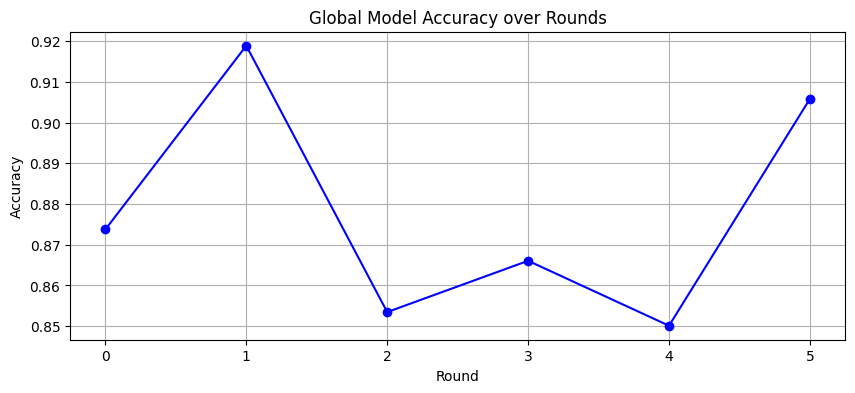

Generating Confusion Matrix (this may take a moment)...


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=9603) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


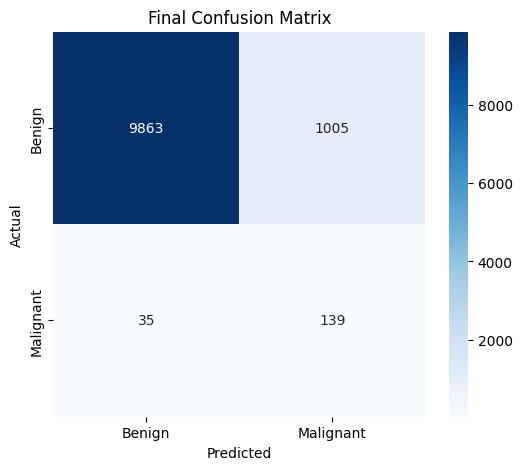


Classification Report:

              precision    recall  f1-score   support

      Benign       1.00      0.91      0.95     10868
   Malignant       0.12      0.80      0.21       174

    accuracy                           0.91     11042
   macro avg       0.56      0.85      0.58     11042
weighted avg       0.98      0.91      0.94     11042



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def visualize_results(history, final_params):

    acc_points = history.metrics_centralized["accuracy"]
    rounds = [x[0] for x in acc_points]
    acc = [x[1] for x in acc_points]

    plt.figure(figsize=(10, 4))
    plt.plot(rounds, acc, marker='o', color='b')
    plt.title("Global Model Accuracy over Rounds")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

    print("Generating Confusion Matrix (this may take a moment)...")
    model = get_model()
    set_parameters(model, final_params)
    model.to(DEVICE)
    model.eval()

    val_loader = load_data_partition(0, NUM_CLIENTS, BATCH_SIZE)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            y_true.extend(labels.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy().flatten())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.title("Final Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))


if FINAL_MODEL_PARAMS:
    visualize_results(history, FINAL_MODEL_PARAMS)
else:
    print("Simulation did not run or failed to save parameters.")

Fine-tuning on alternative data - ISIC 2018

In [12]:
#--- Setup for fine-tuning ---

# 1. Get the architecture of the model used in the simulation
# (You must have this function defined elsewhere in your environment)
# The `get_model` function creates an untrained model instance.
final_model = get_model()
final_model.to(DEVICE)

# 2. Check if the simulation was run and parameters were saved
if FINAL_MODEL_PARAMS is not None:
    # 3. Load the final aggregated parameters into the model instance
    set_parameters(final_model, FINAL_MODEL_PARAMS)
    print("Successfully loaded final federated model parameters.")
else:
    print("Error: FINAL_MODEL_PARAMS is None. Ensure simulation ran successfully.")

Successfully loaded final federated model parameters.


In [13]:

!unzip "/content/drive/MyDrive/AITDM/train_2018.zip" -d /content/train_2018/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train_2018/ISIC_0029303.jpg  
  inflating: /content/train_2018/ISIC_0029302.jpg  
  inflating: /content/train_2018/ISIC_0029301.jpg  
  inflating: /content/train_2018/ISIC_0029300.jpg  
  inflating: /content/train_2018/ISIC_0029299.jpg  
  inflating: /content/train_2018/ISIC_0029298.jpg  
  inflating: /content/train_2018/ISIC_0029297.jpg  
  inflating: /content/train_2018/ISIC_0029296.jpg  
  inflating: /content/train_2018/ISIC_0029295.jpg  
  inflating: /content/train_2018/ISIC_0029294.jpg  
  inflating: /content/train_2018/ISIC_0029293.jpg  
  inflating: /content/train_2018/ISIC_0029292.jpg  
  inflating: /content/train_2018/ISIC_0029291.jpg  
  inflating: /content/train_2018/ISIC_0029290.jpg  
  inflating: /content/train_2018/ISIC_0029289.jpg  
  inflating: /content/train_2018/ISIC_0029288.jpg  
  inflating: /content/train_2018/ISIC_0029287.jpg  
  inflating: /content/train_2018/ISIC_0029286.jpg  
  inflating: 

In [14]:
class ISIC2018Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        if not img_name.endswith('.jpg'):
            img_name += '.jpg'

        img_path = os.path.join(self.img_dir, img_name)

        if os.path.exists(img_path):
            image = Image.open(img_path).convert('RGB')
        else:
            image = Image.new('RGB', (224, 224))

        # Target: 0 (Benign) or 1 (Malignant) -> Float for BCE Loss
        label = torch.tensor([self.df.iloc[idx]['Malignant']], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [15]:
CSV_2018_PATH = "/content/trustworthy-federated-skin-lesion/labels/ISIC_2018_Training_GroundTruth.csv"
df_2018 = pd.read_csv(CSV_2018_PATH)
IMG_2018_DIR = "content/train_2018"

transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

full_2018_dataset = ISIC2018Dataset(df_2018, IMG_DIR, transform=transform)
print(len(full_2018_dataset))


10015


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [16]:
isic_2018_dataloader = DataLoader(
    dataset=full_2018_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Set to True for training data
    num_workers=2,
    pin_memory=True         # Highly recommended for GPU training
)

print(f"Total number of batches in the DataLoader: {len(isic_2018_dataloader)}")

Total number of batches in the DataLoader: 313


In [57]:
# Example fine-tuning function (assuming PyTorch/similar structure)
def fine_tune_model(model, new_data_loader, epochs=5, lr=1e-6):
    pos_weight = torch.tensor([4.5]).to(DEVICE)
    # Set the model to training mode
    model.train()

    # Define a new optimizer with a potentially lower learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print(f"Starting fine-tuning for {epochs} epochs...")
    for epoch in range(epochs):
        for inputs, labels in new_data_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"Fine-tuning Epoch {epoch+1} finished, Loss: {loss.item():.4f}")

    # Save the final fine-tuned model
    torch.save(model.state_dict(), '/content/drive/My Drive/final_fine_tuned_model.pth')
    print("Fine-tuned model saved.")


# Assuming you have defined target_train_loader
# fine_tune_model(final_model, target_train_loader, epochs=5)

In [51]:
fine_tune_model(final_model, isic_2018_dataloader, epochs=5)

Starting fine-tuning for 5 epochs...


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=9603) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


Fine-tuning Epoch 1 finished, Loss: 1.2319
Fine-tuning Epoch 2 finished, Loss: 1.0251
Fine-tuning Epoch 3 finished, Loss: 1.1615
Fine-tuning Epoch 4 finished, Loss: 0.9510
Fine-tuning Epoch 5 finished, Loss: 1.1615
Fine-tuned model saved.


In [52]:

!unzip "/content/drive/MyDrive/AITDM/test_2018.zip" -d /content/test_2018/

Archive:  /content/drive/MyDrive/AITDM/test_2018.zip
replace /content/test_2018/ISIC_0036062.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [53]:
CSV_2018_TEST_PATH = "/content/trustworthy-federated-skin-lesion/labels/ISIC_2018_Test_GroundTruth.csv"
df_test_2018 = pd.read_csv(CSV_2018_TEST_PATH)
IMG_2018_TEST_DIR = "content/test_2018"


test_2018_dataset = ISIC2018Dataset(df_test_2018, IMG_2018_TEST_DIR, transform=transform)
print(len(test_2018_dataset))





1512


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [54]:
isic_2018_test_dataloader = DataLoader(
    dataset=test_2018_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Set to True for training data
    num_workers=2,
    pin_memory=True         # Highly recommended for GPU training
)

print(f"Total number of batches in the DataLoader: {len(isic_2018_dataloader)}")

Total number of batches in the DataLoader: 313


In [55]:
def visualize_fine_tuning_results(model, test_loader):
    """Evaluates the fine-tuned model and displays Confusion Matrix/Report."""

    # Set the model to evaluation mode
    model.eval()

    y_true = []
    y_pred = []

    print("\nGenerating Confusion Matrix and Report for fine-tuned model...")

    # Ensure all tensors are on the correct device (DEVICE)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)

            # Forward Pass
            outputs = model(images)

            # Convert logits to binary predictions (assuming binary classification)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            # Move results back to CPU for numpy/sklearn
            y_true.extend(labels.cpu().numpy().flatten())
            y_pred.extend(preds.cpu().numpy().flatten())

    # Calculate and plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # The visualization logic from your original function
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.title("Fine-Tuned Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show() #

    # Print Classification Report
    print("\nClassification Report (Fine-Tuned):\n")
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

# Assuming you have a separate target_eval_loader for the new dataset
# target_eval_loader = create_data_loader_for_eval(new_dataset_split)

# Call the function with the loaded model and its evaluation data


Successfully loaded fine-tuned model state.

Generating Confusion Matrix and Report for fine-tuned model...


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=9603) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


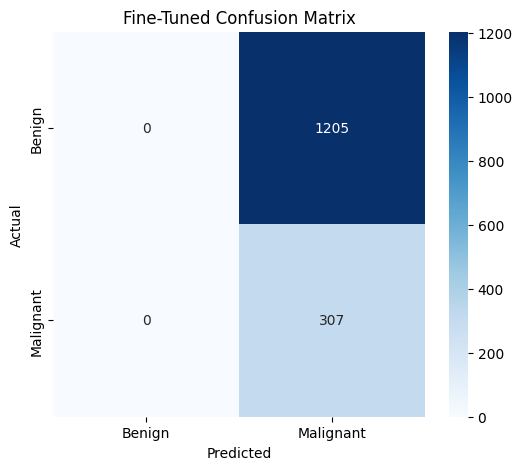


Classification Report (Fine-Tuned):

              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00      1205
   Malignant       0.20      1.00      0.34       307

    accuracy                           0.20      1512
   macro avg       0.10      0.50      0.17      1512
weighted avg       0.04      0.20      0.07      1512



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

In [56]:
# Load the model architecture
fine_tuned_model = get_model()
fine_tuned_model.to(DEVICE)

# Load the saved state dictionary
try:
    fine_tuned_model.load_state_dict(
        torch.load('/content/drive/My Drive/final_fine_tuned_model.pth')
    )
    print("Successfully loaded fine-tuned model state.")
    visualize_fine_tuning_results(fine_tuned_model, isic_2018_test_dataloader)
except FileNotFoundError:
    print("Error: Fine-tuned model file not found.")
    # Handle the error, maybe exit or use the model as is